# Repeated partial swap of two transmons — joint populations vs. swap index

Two 2-level transmons; the **same** partial-swap unitary
$U = e^{-iH}$ with
$H = \theta\,(\sigma^+\!\otimes\sigma^- + \sigma^-\!\otimes\sigma^+) + \tfrac{\delta}{2}\,(n_1 - n_2)$,
applied $N$ times — coherently by default, or with transmon 2 **reset to $|0\rangle$ after
every swap** (`reset_q2`). For a swap pulse of duration $t_p$
the two knobs are $\theta = g\,t_p$ (swap angle; $\pi/2$ = full iSWAP at resonance;
collisional link $\theta = \sqrt{\gamma\,dt}$) and $\delta = (\omega_1 - \omega_2)\,t_p$
(detuning phase per swap; $0$ = resonant).

This is the coherent counterpart of `collisional simulation of dynamics.ipynb` (and of
`../qc_swap_paramreset_collisional.ipynb`): at $\delta = 0$ the per-collision unitary is
identical, but by default the partner transmon is *not* reset each round, so populations
oscillate instead of damping. Setting `reset_q2 = True` restores the collisional model.

Starting from $|10\rangle$ (transmon 1 excited), the generalized-Rabi solution on the swap
index is
$$P_{01}(i) = \frac{\theta^2}{\Omega^2}\,\sin^2(i\,\Omega),\qquad
P_{10} = 1 - P_{01},\qquad \Omega = \sqrt{\theta^2 + \delta^2/4},$$
and $P_{00} = P_{11} = 0$: $H$ conserves excitation number, so detuning costs transfer
contrast ($\theta^2/\Omega^2$) and speeds up the oscillation, but causes no leakage in the
2-level model. Sweeping $\delta$ against $i$ gives the swap chevron.

**Reset mode** (`reset_q2 = True`) — the swap-based param-reset of `LCH_qc_swap_paramreset`:
each round is *swap → reset q2*, the state becomes mixed, and the excitation decays
geometrically instead of oscillating,
$$P_{10}(i) = p^{\,i},\qquad p = 1 - \frac{\theta^2}{\Omega^2}\,\sin^2\Omega,$$
with $p = \cos^2\theta$ at $\delta = 0$ (the collisional amplitude damping,
$\theta = \sqrt{\gamma\,dt}$). Populations are recorded at **both** points of the round —
after the swap (before the reset), where $P_{01}(i) = (1-p)\,p^{\,i-1}$ is the population
each reset dumps, and after the full round (after the reset), where $P_{01} = 0$ — and
plotted side by side.

We track the joint **computational** basis $|00\rangle, |01\rangle, |10\rangle, |11\rangle$
($|q_1 q_2\rangle$; $1$ = excited, $0$ = ground) because that is what the experiment
measures; at resonance the eigenstates of $H$ are $|00\rangle$, $|11\rangle$,
$(|01\rangle \pm |10\rangle)/\sqrt{2}$ (whose populations are constant under $U$), and
detuning tilts the single-excitation pair toward the bare states.

In [19]:
# Cell 1 — setup & manual knobs
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

theta = 0.632  # swap angle per application; pi/2 = full iSWAP; collisional link: theta = sqrt(gamma*dt)
delta = 0        # detuning phase per swap: (w1 - w2) * t_swap; 0 = resonant
N = 10            # number of partial swaps
reset_q2 = False  # reset transmon 2 to |0> after each swap (collisional / param-reset mode)

# Same qutip convention as the collisional notebooks: basis(2,0) = |1> (excited), basis(2,1) = |0> (ground)
ket_1, ket_0 = qt.basis(2, 0), qt.basis(2, 1)
KETS = {"1": ket_1, "0": ket_0}

ORDER = ["11", "10", "01", "00"]  # joint basis (transmon1, transmon2), fixed order
STATES = {s: qt.tensor(KETS[s[0]], KETS[s[1]]) for s in ORDER}
TEX = {s: rf"$|{s}\rangle$" for s in ORDER}

psi0 = STATES["10"]  # transmon 1 excited, transmon 2 in ground

In [20]:
# Cell 2 — apply U N times (optionally resetting q2 each round), record joint populations
sp, sm = qt.sigmap(), qt.sigmam()
s0, n = qt.qeye(2), sp * sm  # n = |1><1|
H = theta * (qt.tensor(sp, sm) + qt.tensor(sm, sp)) \
    + 0.5 * delta * (qt.tensor(n, s0) - qt.tensor(s0, n))
U = qt.Qobj.expm(-1j * H)

# density matrix (the reset makes the state mixed); identical to ket evolution when reset_q2=False
rho_0 = qt.ket2dm(ket_0)

def pops(rho):
    return [qt.expect(STATES[s].proj(), rho) for s in ORDER]

rho = qt.ket2dm(psi0)
P = np.empty((N + 1, len(ORDER)))  # P[i, k] = population of ORDER[k] after swap i, BEFORE the reset
P_round = np.empty_like(P)         # after the full round (swap + reset); == P when reset_q2=False
P[0] = P_round[0] = pops(rho)
for i in range(1, N + 1):
    rho = U * rho * U.dag()                    # swap #i
    P[i] = pops(rho)
    if reset_q2:
        rho = qt.tensor(rho.ptrace(0), rho_0)  # reset q2 -> |0><0|
    P_round[i] = pops(rho)

i_swap = np.arange(N + 1)

# self-checks against the analytic solutions for psi0 = |10>
Omega = np.sqrt(theta**2 + (delta / 2) ** 2)  # effective rotation per swap
C = (theta / Omega) ** 2 if Omega else 1.0    # transfer contrast
assert np.allclose(P.sum(axis=1), 1.0) and np.allclose(P_round.sum(axis=1), 1.0), \
    "populations do not sum to 1"
if reset_q2:
    # geometric decay: survival p per round; before the reset |01> holds the dumped population
    p_surv = 1.0 - C * np.sin(Omega) ** 2
    P_10_th = p_surv ** i_swap
    P_01_th = np.concatenate([[0.0], (1.0 - p_surv) * P_10_th[:-1]])
    assert np.allclose(P[:, ORDER.index("10")], P_10_th), "P_10 != p^i"
    assert np.allclose(P[:, ORDER.index("01")], P_01_th), "P_01 != (1-p) p^(i-1)"
    assert np.allclose(P_round[:, ORDER.index("10")], P_10_th), "P_10 (after reset) != p^i"
    assert np.allclose(P_round[:, ORDER.index("01")], 0.0), "|01> nonzero after reset"
    assert np.allclose(P[:, ORDER.index("11")], 0.0), "|11> leaked"
    n_e = np.inf if p_surv >= 1 else (0.0 if p_surv <= 0 else -1.0 / np.log(p_surv))
    print(f"OK: theta = {theta:.4f}, delta = {delta:.4f}, Omega = {Omega:.4f} rad/swap, "
          f"p = {p_surv:.3f}/round (1/e after {n_e:.1f} rounds), N = {N}; all self-checks passed")
else:
    # generalized-Rabi solution on the swap index
    P_01_th = C * np.sin(i_swap * Omega) ** 2
    assert np.allclose(P, P_round), "records differ without reset"
    assert np.allclose(P[:, ORDER.index("01")], P_01_th), "P_01 != Rabi formula"
    assert np.allclose(P[:, ORDER.index("10")], 1.0 - P_01_th), "P_10 != 1 - P_01"
    assert np.allclose(P[:, [ORDER.index("11"), ORDER.index("00")]], 0.0), "|11>/|00> leaked"
    print(f"OK: theta = {theta:.4f}, delta = {delta:.4f}, Omega = {Omega:.4f} rad/swap, "
          f"contrast = {C:.3f}, N = {N}; all self-checks passed")

OK: theta = 0.6320, delta = 0.0000, Omega = 0.6320 rad/swap, contrast = 1.000, N = 10; all self-checks passed


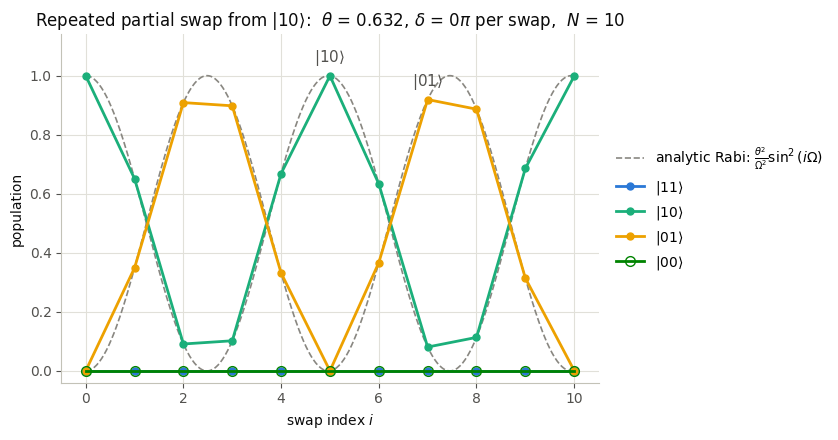

In [21]:
# Cell 3 — populations vs. swap index (points = circuit, dashed grey = analytic)
COLORS = {"11": "#2a78d6", "10": "#1baf7a", "01": "#eda100", "00": "#008300"}
INK, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"

i_dense = np.linspace(0, N, 400)

def draw(ax, Pmat, analytic, panel_title=None):
    """One populations-vs-swap-index panel: dashed analytic curves + circuit points."""
    for y, lbl in analytic:
        ax.plot(i_dense, y, "--", color="#898781", lw=1.2, label=lbl)
    # |00> can lie exactly on top of |11>: open markers keep the blue dots visible
    MSTYLE = {"00": dict(mfc="none", ms=7)}
    for k, s in enumerate(ORDER):
        style = dict(color=COLORS[s], lw=2, ms=5) | MSTYLE.get(s, {})
        ax.plot(i_swap, Pmat[:, k], "o-", label=TEX[s], **style)
    # direct labels on the single-excitation curves, at each one's peak (skip flat-zero curves)
    for s in ("01", "10"):
        y = Pmat[:, ORDER.index(s)]
        i_pk = int(np.argmax(y[1:]) + 1)
        if y[i_pk] < 0.02:
            continue
        ax.annotate(TEX[s], (i_pk, y[i_pk]), xytext=(0, 10),
                    textcoords="offset points", ha="center", color=MUTED, fontsize=11)
    ax.set_xlabel("swap index $i$", color=INK)
    ax.set_ylim(-0.04, 1.14)
    if panel_title:
        ax.set_title(panel_title, color=INK, fontsize=11)
    ax.grid(color=GRID, lw=0.8)
    ax.tick_params(colors=MUTED)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

if reset_q2:
    p_dense = p_surv ** i_dense
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7), sharey=True)
    draw(axes[0], P, [(p_dense, r"analytic decay: $p^{\,i}$")],
         "after swap $i$ (before reset)")
    draw(axes[1], P_round, [(p_dense, None), (1.0 - p_dense, None)],
         "after round $i$ (after reset)")
    axes[0].set_ylabel("population", color=INK)
    axes[1].legend(*axes[0].get_legend_handles_labels(),
                   loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.suptitle(rf"Repeated partial swap from $|10\rangle$, q2 reset each round:  "
                 rf"$\theta$ = {theta}, $\delta$ = {delta:.3g} per swap,  "
                 rf"$N$ = {N},  $p$ = {p_surv:.3f}/round", color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
else:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    p_01_dense = C * np.sin(i_dense * Omega) ** 2
    draw(ax, P, [(1.0 - p_01_dense, r"analytic Rabi: $\frac{\theta^2}{\Omega^2}\sin^2(i\Omega)$"),
                 (p_01_dense, None)])
    ax.set_ylabel("population", color=INK)
    ax.set_title(rf"Repeated partial swap from $|10\rangle$:  $\theta$ = {theta:.3g}, "
                 rf"$\delta$ = {delta / np.pi:.3g}$\pi$ per swap,  $N$ = {N}", color=INK)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.tight_layout()
plt.show()